## Importing Libraries

In [60]:
import os
from glob import glob

import numpy as np
import matplotlib.pyplot as plt

import cv2

from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Input, Conv2D, BatchNormalization, Activation, UpSampling2D, Concatenate
from tensorflow.keras.models import Model
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.optimizers import Adam

---

## Importing Data for Understanding

In [35]:
# Setting paths of the dataset
image_dir = r"D:\Oxford Data\data\oxford-iiit-pet\images"  
trimap_dir = r"D:\Oxford Data\data\oxford-iiit-pet\annotations\trimaps"  

# Making lists of all image and trimap files
image_files = sorted(glob(os.path.join(image_dir, "*.jpg")))
trimap_files = sorted(glob(os.path.join(trimap_dir, "*.png")))

In [36]:
print(f"Number of images: {len(image_files)}")
print(f"Number of trimaps: {len(trimap_files)}")

Number of images: 7390
Number of trimaps: 7390


In [37]:
# Checking if the names are matching or not
for i in range(5):
    img_name = os.path.basename(image_files[i])
    trimap_name = os.path.basename(trimap_files[i])
    print(f"Image: {img_name}, Trimap: {trimap_name}")

Image: Abyssinian_1.jpg, Trimap: Abyssinian_1.png
Image: Abyssinian_10.jpg, Trimap: Abyssinian_10.png
Image: Abyssinian_100.jpg, Trimap: Abyssinian_100.png
Image: Abyssinian_101.jpg, Trimap: Abyssinian_101.png
Image: Abyssinian_102.jpg, Trimap: Abyssinian_102.png


---

## Visualizing Real Images & Trimaps

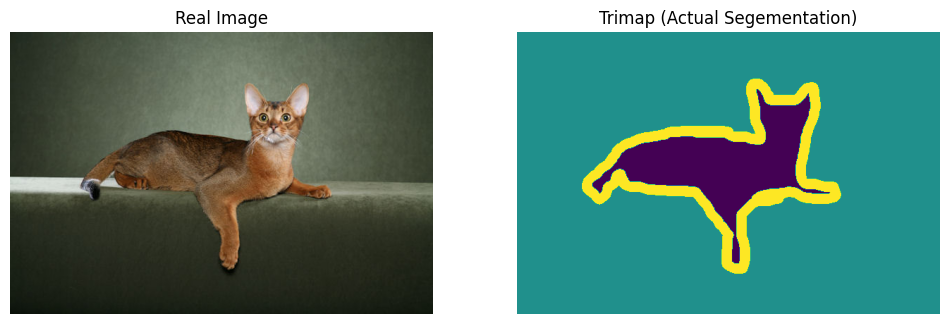

In [38]:
# Visualizing image and it's trimap
def visualize_sample(image_path, trimap_path):
   
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    trimap = cv2.imread(trimap_path, cv2.IMREAD_GRAYSCALE)
    
   
    plt.figure(figsize=(12, 6))
    
    plt.subplot(1, 2, 1)
    plt.imshow(image)
    plt.title("Real Image")
    plt.axis("off")
    
    plt.subplot(1, 2, 2)
    plt.imshow(trimap, cmap="viridis")
    plt.title("Trimap (Actual Segementation)")
    plt.axis("off")
    
    plt.show()

for i in range(1):
    visualize_sample(image_files[i], trimap_files[i])

---

## Preprocessing Images

In [39]:
# Processing the images
IMG_SIZE = 224

real_images = []  # Images
segmented_images = []  # Trimaps (Actual Segmentation)


num_samples = 1000 
sample_indices = np.random.choice(len(image_files), min(num_samples, len(image_files)), replace=False)

for idx in sample_indices:
    img_path = image_files[idx]
    trimap_path = trimap_files[idx]

    # Read and check if the image is valid
    img = cv2.imread(img_path)
    if img is None:
        print(f"Warning: Skipping unreadable image -> {img_path}")
        continue  # Skip unreadable images

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = img / 255.0  

    # Read and check if the trimap is valid
    trimap = cv2.imread(trimap_path, cv2.IMREAD_GRAYSCALE)
    if trimap is None:
        print(f"Warning: Skipping unreadable trimap -> {trimap_path}")
        continue  # Skip unreadable trimaps

    trimap = cv2.resize(trimap, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_NEAREST)
    trimap = trimap - 1  # Convert trimap values to zero-based indexing 

    real_images.append(img)
    segmented_images.append(trimap)

In [40]:
# Convert to numpy arrays
real_images = np.array(real_images, dtype=np.float32)
segmented_images = np.array(segmented_images, dtype=np.int32)

print(f"Preprocessed {real_images.shape[0]} images and {segmented_images.shape[0]} trimaps.")

Preprocessed 998 images and 998 trimaps.


In [ ]:
# One-hot encoding the labels
y_categorical = to_categorical(segmented_images, num_classes=3)

In [41]:
print(f"X shape: {real_images.shape}")
print(f"y shape: {segmented_images.shape}")
print(f"y_categorical shape: {y_categorical.shape}")

X shape: (998, 224, 224, 3)
y shape: (998, 224, 224)
y_categorical shape: (998, 224, 224, 3)


---

## Splitting Data

In [42]:
# Splitting off the test set (10% of data)
x_temp, x_test, y_temp, y_test = train_test_split(real_images, y_categorical, test_size=0.1, random_state=42)

# SplitTING the remaining data into training (70%) and validation (20%)
x_train, x_val, y_train, y_val = train_test_split(x_temp, y_temp, test_size=0.22, random_state=42)

In [43]:
print(f"Training images: {x_train.shape[0]} ({x_train.shape[0]/real_images.shape[0]:.1%} of total)")
print(f"Validation images: {x_val.shape[0]} ({x_val.shape[0]/real_images.shape[0]:.1%} of total)")
print(f"Test images: {x_test.shape[0]} ({x_test.shape[0]/real_images.shape[0]:.1%} of total)")

Training images: 700 (70.1% of total)
Validation images: 198 (19.8% of total)
Test images: 100 (10.0% of total)


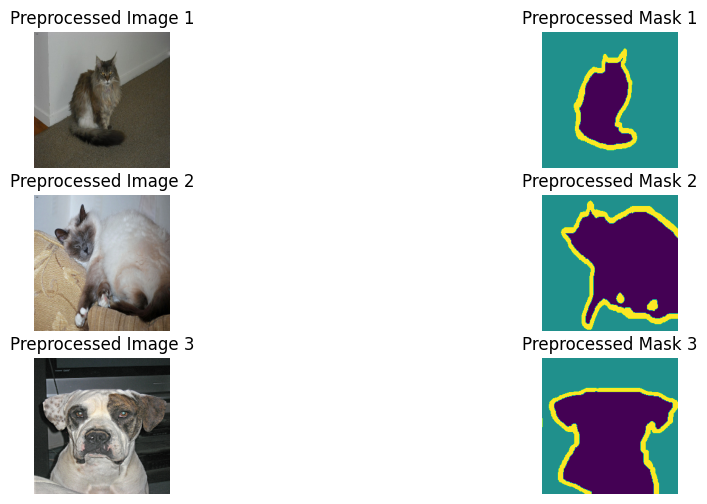

In [45]:
# Visualize preprocessed data
plt.figure(figsize=(12, 6))

for i in range(3):
    # Get a random sample from the training set
    idx = np.random.randint(0, len(x_train))

    plt.subplot(3, 2, 2*i+1)
    plt.imshow(x_train[idx])
    plt.title(f"Preprocessed Image {i+1}")
    plt.axis("off")

    plt.subplot(3, 2, 2*i+2)
    mask = np.argmax(y_train[idx], axis=-1)
    plt.imshow(mask, cmap="viridis")
    plt.title(f"Preprocessed Mask {i+1}")
    plt.axis("off")

plt.show()

---

## Building the Model and Evaluation Metrices

In [48]:
# IoU Metric
def iou_metric(y_true, y_pred):

    y_pred = tf.cast(tf.argmax(y_pred, axis=-1), tf.float32)
    y_true = tf.cast(tf.argmax(y_true, axis=-1), tf.float32)

    # Calculate IoU for each class separately
    class_scores = []
    for i in range(3):  
        true_class = tf.cast(tf.equal(y_true, i), tf.float32)
        pred_class = tf.cast(tf.equal(y_pred, i), tf.float32)

        intersection = tf.reduce_sum(true_class * pred_class)
        union = tf.reduce_sum(true_class) + tf.reduce_sum(pred_class) - intersection

        iou = (intersection + tf.keras.backend.epsilon()) / (union + tf.keras.backend.epsilon())
        class_scores.append(iou)

    # Return mean IoU across all classes
    return tf.reduce_mean(class_scores)

In [49]:
# Dice Coefficient
def dice_coefficient(y_true, y_pred):
   
    y_pred = tf.cast(tf.argmax(y_pred, axis=-1), tf.float32)
    y_true = tf.cast(tf.argmax(y_true, axis=-1), tf.float32)

    # Calculate Dice for each class
    class_scores = []
    for i in range(3):  
        true_class = tf.cast(tf.equal(y_true, i), tf.float32)
        pred_class = tf.cast(tf.equal(y_pred, i), tf.float32)

        intersection = tf.reduce_sum(true_class * pred_class)
        dice = (2. * intersection + tf.keras.backend.epsilon()) / (
            tf.reduce_sum(true_class) + tf.reduce_sum(pred_class) + tf.keras.backend.epsilon())
        class_scores.append(dice)

    # Return mean Dice across all classes
    return tf.reduce_mean(class_scores)

In [50]:
# Main Model
input_shape = (IMG_SIZE, IMG_SIZE, 3)
inputs = Input(input_shape)

# Encoder 
base_model = MobileNetV2(include_top=False, weights="imagenet", input_tensor=inputs)

# Extracting features from different layers for skip connections
layer_names = [
    "block_1_expand_relu",   # 112x112
    "block_3_expand_relu",   # 56x56
    "block_6_expand_relu",   # 28x28
    "block_13_expand_relu",  # 14x14
    "block_16_project"       # 7x7
]
layers = [base_model.get_layer(name).output for name in layer_names]

# Create the feature extraction model
encoder = Model(inputs=inputs, outputs=layers)

encoder.trainable = True

# Decoder
x = layers[-1]
skips = layers[:-1]

# Upsample and merging with skip connections
for skip in reversed(skips):
    x = UpSampling2D(size=(2, 2))(x)
    concat = Concatenate()([x, skip])

    x = Conv2D(256, 3, padding="same")(concat)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)

    x = Conv2D(256, 3, padding="same")(x)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)

# Final upsampling and output layer
x = UpSampling2D(size=(2, 2))(x)
x = Conv2D(128, 3, padding="same")(x)
x = BatchNormalization()(x)
x = Activation("relu")(x)

outputs = Conv2D(3, 1, activation="softmax")(x)

In [51]:
# Create the model
model = Model(inputs=inputs, outputs=outputs)

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='categorical_crossentropy',  
              metrics=['accuracy', iou_metric, dice_coefficient])


In [52]:
callbacks = [
    ModelCheckpoint("best_segmentation_checkpoint.h5", save_best_only=True, verbose=1),
    EarlyStopping(monitor="val_loss", patience=10, verbose=1)
]

BATCH_SIZE = 8
EPOCHS = 20

---

## Training the Model

In [53]:
history = model.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    callbacks=callbacks
)


Epoch 1/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7420 - dice_coefficient: 0.6602 - iou_metric: 0.5400 - loss: 0.6219   
Epoch 1: val_loss improved from inf to 0.99835, saving model to best_segmentation_checkpoint.h5

88/88 ━━━━━━━━━━━━━━━━━━━━ 195s 1s/step - accuracy: 0.7430 - dice_coefficient: 0.6612 - iou_metric: 0.5412 - loss: 0.6197 - val_accuracy: 0.7811 - val_dice_coefficient: 0.6751 - val_iou_metric: 0.5498 - val_loss: 0.9983
Epoch 2/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 388ms/step - accuracy: 0.9047 - dice_coefficient: 0.8374 - iou_metric: 0.7416 - loss: 0.2497
Epoch 2: val_loss improved from 0.99835 to 0.32065, saving model to best_segmentation_checkpoint.h5

88/88 ━━━━━━━━━━━━━━━━━━━━ 40s 457ms/step - accuracy: 0.9047 - dice_coefficient: 0.8374 - iou_metric: 0.7416 - loss: 0.2497 - val_accuracy: 0.8990 - val_dice_coefficient: 0.8289 - val_iou_metric: 0.7293 - val_loss: 0.3207
Epoch 3/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 371ms/step - accuracy: 0.9149 - dice_coefficient:

---

# Making Predictions & Visualizing Training & Validation

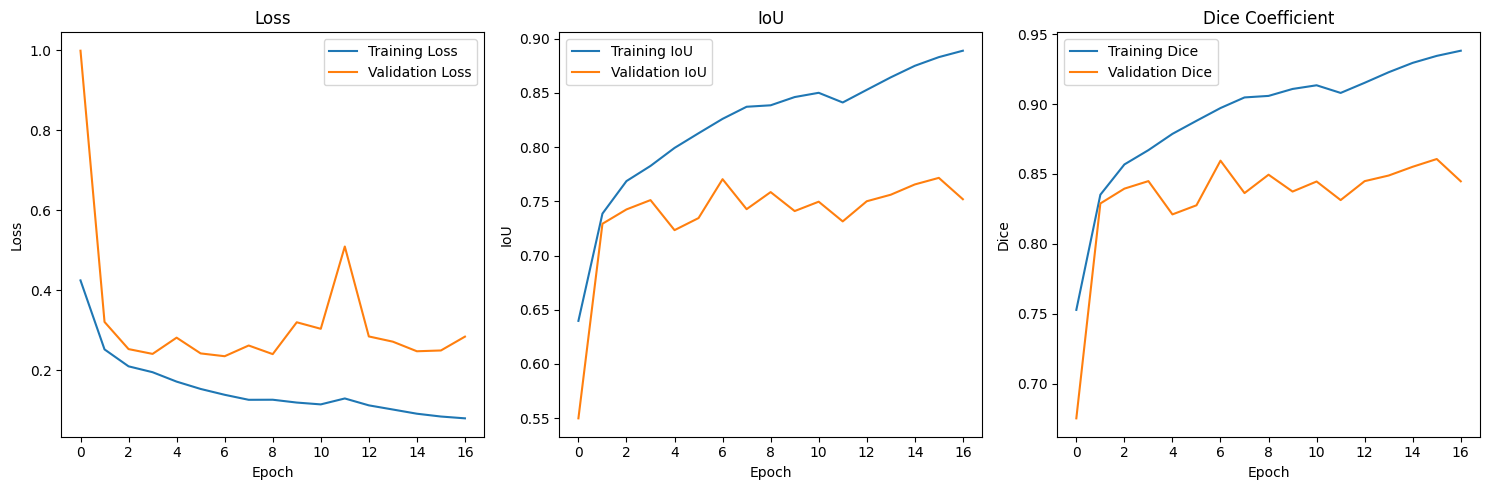

In [55]:
# Plot training history for all metrics
plt.figure(figsize=(15, 5))

# Loss plot
plt.subplot(1, 3, 1)
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

# IoU plot
plt.subplot(1, 3, 2)
plt.plot(history.history["iou_metric"], label="Training IoU")
plt.plot(history.history["val_iou_metric"], label="Validation IoU")
plt.title("IoU")
plt.xlabel("Epoch")
plt.ylabel("IoU")
plt.legend()

# Dice coefficient plot
plt.subplot(1, 3, 3)
plt.plot(history.history["dice_coef"], label="Training Dice")
plt.plot(history.history["val_dice_coef"], label="Validation Dice")
plt.title("Dice Coefficient")
plt.xlabel("Epoch")
plt.ylabel("Dice")
plt.legend()

plt.tight_layout()
plt.show()

In [56]:
# Make predictions on validation data
y_pred = model.predict(x_val)

7/7 ━━━━━━━━━━━━━━━━━━━━ 45s 1s/step


In [ ]:
y_pred_classes = np.argmax(y_pred, axis=-1)
y_val_classes = np.argmax(y_val, axis=-1)

In [57]:
# Getting the best metric
print("The best Metrices:")
val_results = model.evaluate(x_val, y_val, verbose=1)


The best Metric:
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 359ms/step - accuracy: 0.9128 - dice_coef: 0.8438 - iou_metric: 0.7499 - loss: 0.2851



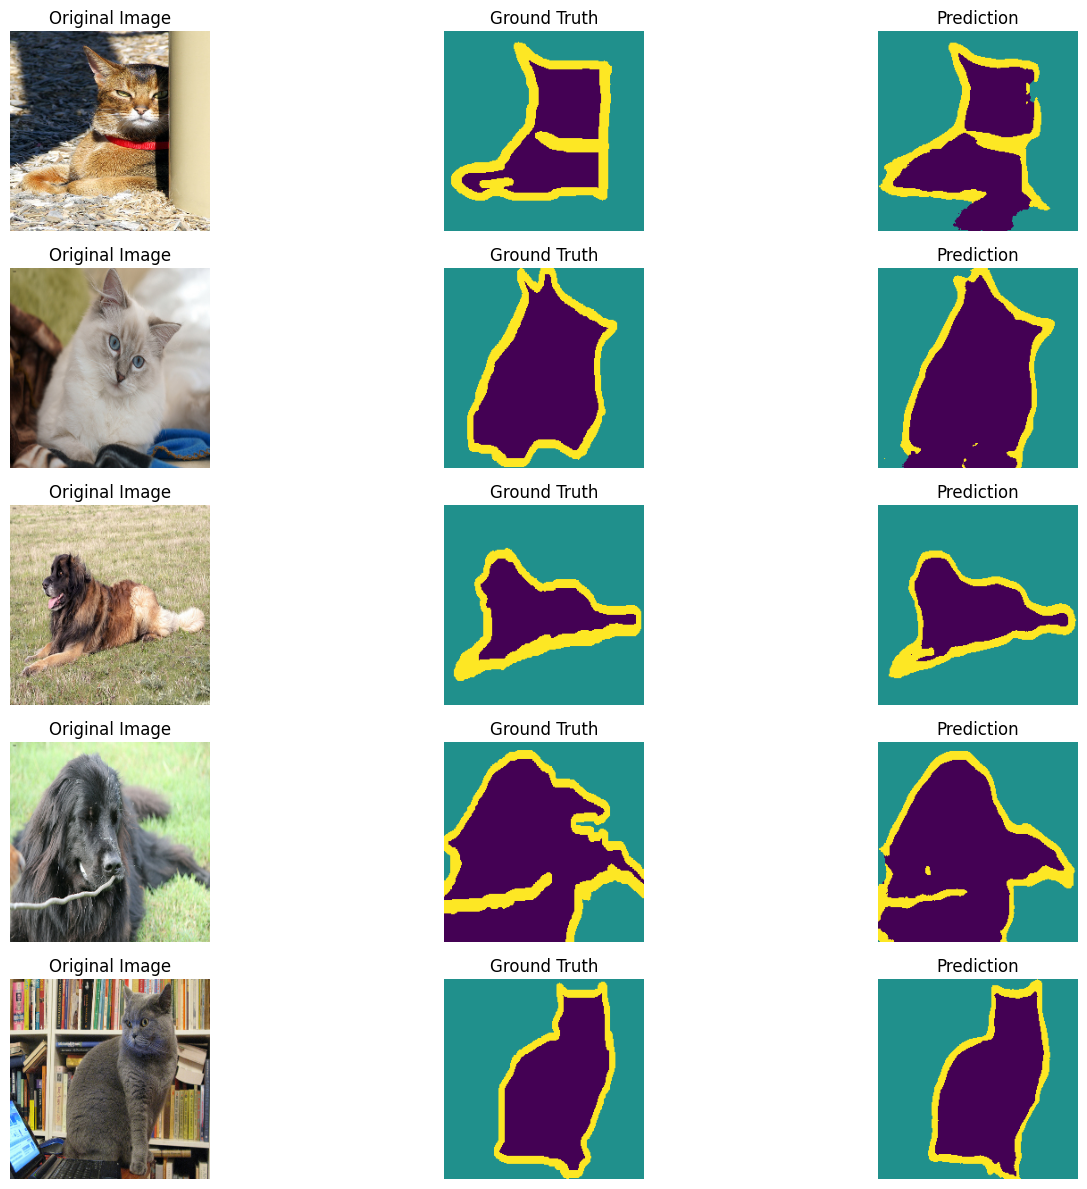

In [54]:
# Visualize predictions
plt.figure(figsize=(15, 12))

for i in range(5):
    idx = np.random.randint(0, len(x_val))

    # Real Iage
    plt.subplot(5, 3, 3*i+1)
    plt.imshow(x_val[idx])
    plt.title("Original Image")
    plt.axis("off")

    # Real Segmentation
    plt.subplot(5, 3, 3*i+2)
    plt.imshow(np.argmax(y_val[idx], axis=-1), cmap="viridis")
    plt.title("Ground Truth")
    plt.axis("off")

    # Predicted Segmentation
    plt.subplot(5, 3, 3*i+3)
    pred_mask = y_pred[idx]
    pred_mask = np.argmax(pred_mask, axis=-1)
    plt.imshow(pred_mask, cmap="viridis")
    plt.title("Prediction")
    plt.axis("off")

plt.show()

---